# MACHINE LEARNING 

### BUSINESS UNDERSTANDING

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#### DATA COLLECTION

In [2]:
insurance_data=pd.read_csv(filepath_or_buffer="insurance data.csv")
insurance_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


#### DATA UNDERSTANDING

In [3]:
insurance_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

In [4]:
insurance_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
insurance_data.shape

(1340, 7)

#### DATA PREPARATION

In [6]:
insurance_data.dropna(inplace=True)
insurance_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [7]:
insurance_data.shape

(1096, 7)

##### NOTE:
1.Client have given the dataset range (1340,7) , but that datasets having missing values so i removed missing values now it is (1096,7), 
2.I must inform to my client and get his/ her approval for further procedure  

##### DATA SEGMENTATION

In [8]:
x=insurance_data.drop(labels=["CASENUM","ATTORNEY"],axis=1)
x

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [9]:
y=insurance_data.drop(labels=["CLMSEX","CLMINSUR","SEATBELT","CLMAGE","LOSS","CASENUM"],axis=1)
y

,ATTORNEY
0,0
1,1
2,1
3,0
4,1
...,...
1334,1
1336,0
1337,1
1338,0


#### MODEL BUILDING

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,shuffle=True)
x_train,x_test,y_train,y_test

(      CLMSEX  CLMINSUR  SEATBELT  CLMAGE   LOSS
 104      0.0       1.0       0.0     7.0  0.589
 1255     0.0       1.0       0.0    48.0  0.455
 1329     1.0       1.0       0.0    33.0  0.535
 1093     1.0       1.0       0.0    10.0  5.880
 1068     0.0       1.0       0.0    17.0  0.050
 ...      ...       ...       ...     ...    ...
 336      0.0       1.0       0.0    46.0  4.159
 438      1.0       1.0       0.0     6.0  3.883
 1295     1.0       1.0       0.0    18.0  3.180
 569      0.0       1.0       0.0     5.0  1.737
 980      1.0       1.0       0.0     6.0  0.757
 
 [876 rows x 5 columns],
       CLMSEX  CLMINSUR  SEATBELT  CLMAGE    LOSS
 93       0.0       1.0       0.0    31.0   3.018
 1119     1.0       1.0       0.0    60.0   0.300
 167      1.0       0.0       0.0    39.0   0.140
 493      1.0       1.0       0.0    15.0   3.085
 154      1.0       1.0       0.0    41.0   1.579
 ...      ...       ...       ...     ...     ...
 1022     0.0       1.0       0.0  

#### MODEL TRAININNG

In [11]:
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,VotingClassifier
rf_classifier=RandomForestClassifier(n_estimators=100,max_depth=5,random_state=25)
rf_classifier.fit(x_train,y_train.values.ravel())

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
dt_model = DecisionTreeClassifier(max_depth=5,criterion='gini')
dt_model

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
dt_model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


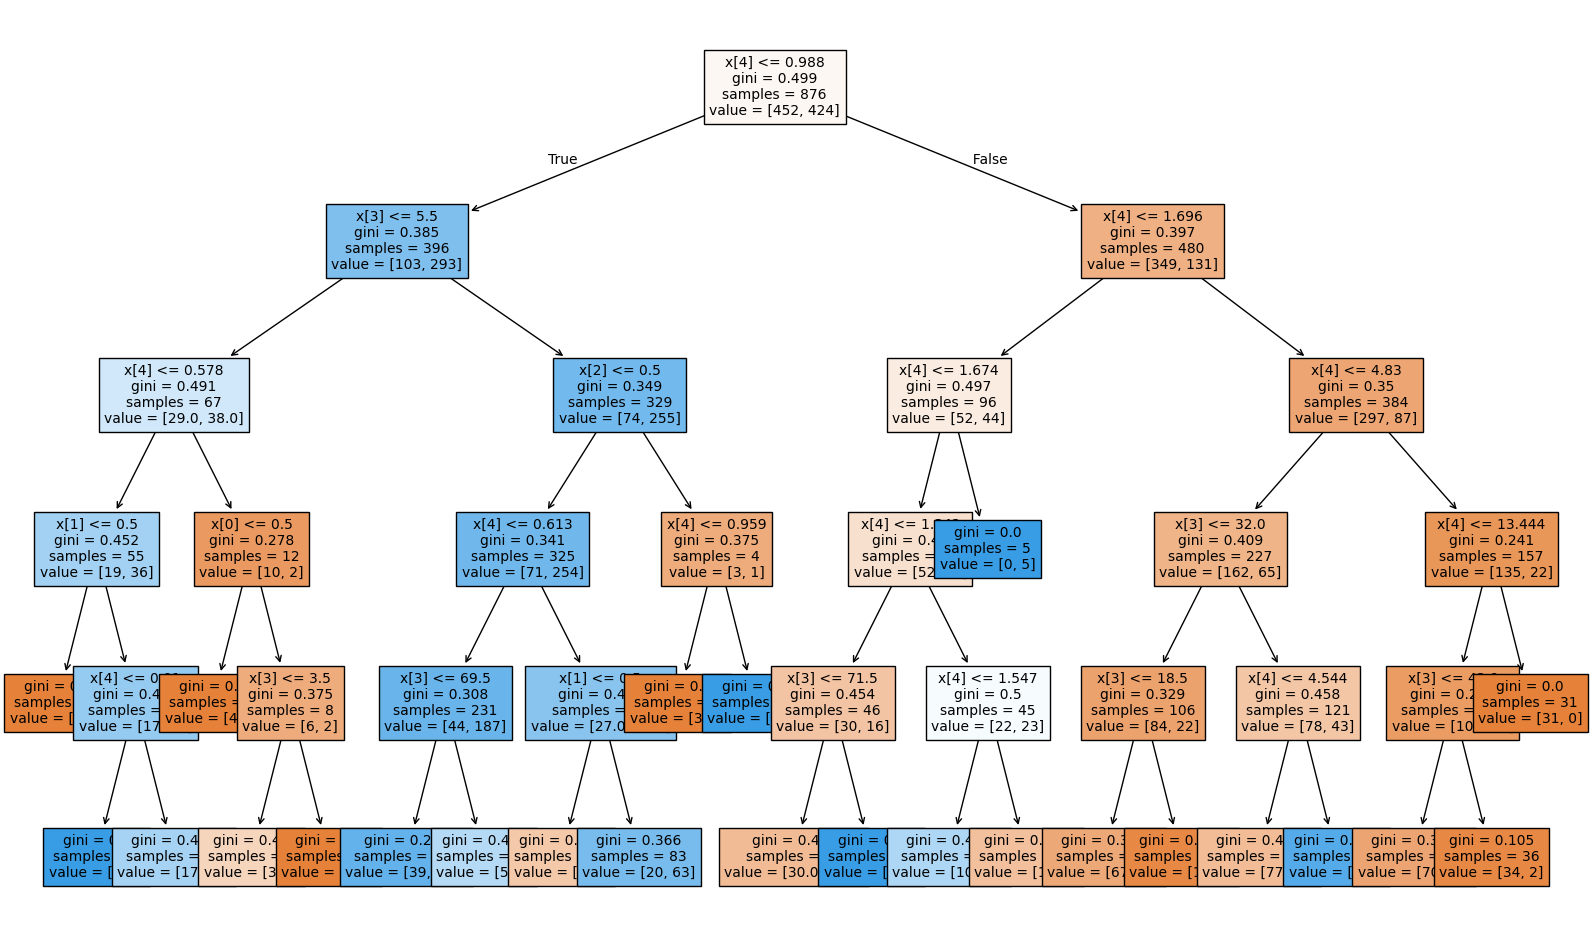

In [14]:
plt.figure(figsize=(20,12))
plot_tree(decision_tree=dt_model,fontsize=10,filled=True)
plt.show()

##### GRID SEARCH CV(CROSS VALIDATION)

In [15]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=rf_classifier,param_grid = {"max_depth":[6,7,8,9,10],
                                                               "criterion":["gini","entropy"],
                                                               "n_estimators":[50,75,100,125,150]})
grid_search.fit(x_train,y_train.values.ravel())
print(grid_search.best_score_)
print(grid_search.best_params_)

0.7294545454545455
{'criterion': 'gini', 'max_depth': 6, 'n_estimators': 125}


#### MODEL TESTING

In [16]:
y_pred_train=dt_model.predict(x_train)
print(y_pred_train)

[1 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1
 1 0 0 0 0 0 1 1 1 1 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1
 1 1 1 0 1 1 1 0 0 0 1 1 1 1 0 0 1 1 0 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0
 1 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 1 1 0 1 1 1 1 1 1 0 0 1
 1 0 0 0 1 1 0 1 1 1 1 1 0 0 1 1 0 0 1 0 1 0 1 1 1 0 1 0 0 1 0 0 1 0 0 0 1
 0 1 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 1 0 1 1 1 1
 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 1 1 1 0 1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 0 1
 0 0 0 1 1 1 1 0 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 0 0 1 1 1
 0 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 0 0 0
 0 1 1 0 1 0 1 0 0 1 1 1 1 1 0 1 0 1 1 0 1 0 0 0 1 0 1 0 1 0 0 1 1 0 0 0 0
 0 1 0 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 1 1 0 1 0 0 1 0 1 1 0 1 0
 0 0 0 1 0 1 0 1 0 0 0 1 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 0 1 0 0 1 0 1 1 0 0
 1 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 0 0 1 1 0 0 1 0 1 1 1 0 1 0 1 0 1 1 1 0
 1 1 1 1 0 0 0 1 1 1 1 1 

#### TESTING ACCURACY

In [17]:
y_pred_test=dt_model.predict(x_test)
print(y_pred_test)

[0 1 1 0 0 1 1 0 1 1 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0 1 0 1 0 0 0 0 1 1 0 1
 0 1 1 1 0 0 1 0 0 0 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 1 0 1 1 0 0 0
 0 0 1 0 0 0 1 0 0 1 0 1 1 1 1 0 1 1 0 1 1 0 0 1 1 0 1 0 1 1 1 0 1 1 1 0 1
 0 1 1 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 0 1 0 0 1 1 1
 0 1 0 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0
 1 1 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1]


#### MODEL EVALUATION

In [18]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve


In [19]:
print(confusion_matrix(y_train,y_pred_train))

[[360  92]
 [106 318]]


In [20]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.77      0.80      0.78       452
           1       0.78      0.75      0.76       424

    accuracy                           0.77       876
   macro avg       0.77      0.77      0.77       876
weighted avg       0.77      0.77      0.77       876



##### TRAINING ACCURACY

In [21]:
fpr,tpr,threshold=roc_curve(y_train,dt_model.predict_proba(x_train)[:,1])
fpr,tpr,threshold

(array([0.        , 0.        , 0.00221239, 0.08849558, 0.13274336,
        0.17035398, 0.19247788, 0.20353982, 0.21017699, 0.22566372,
        0.25221239, 0.42256637, 0.48893805, 0.63716814, 0.7920354 ,
        0.90486726, 1.        ]),
 array([0.        , 0.03066038, 0.04716981, 0.46933962, 0.61792453,
        0.69103774, 0.73113208, 0.75      , 0.75471698, 0.76415094,
        0.77830189, 0.86320755, 0.89622642, 0.94575472, 0.99292453,
        1.        , 1.        ]),
 array([       inf, 1.        , 0.875     , 0.82110092, 0.75903614,
        0.64583333, 0.62962963, 0.61538462, 0.4       , 0.36363636,
        0.33333333, 0.31858407, 0.31818182, 0.23863636, 0.22222222,
        0.05555556, 0.        ]))

0.7732300884955753


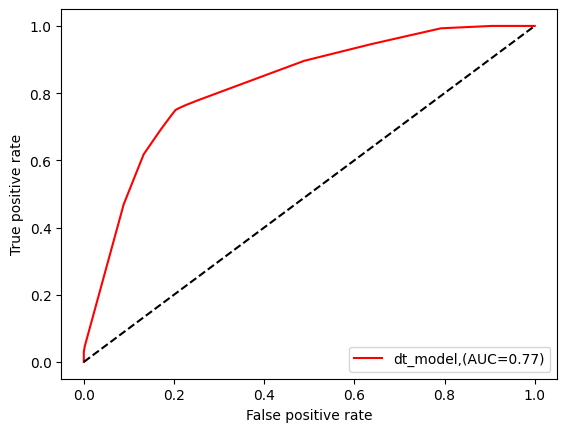

In [22]:
auc=roc_auc_score(y_train,y_pred_train)
print(auc)
import matplotlib.pyplot as plt
plt.plot(fpr,tpr,color="red",label="dt_model,(AUC=%0.2f)"%auc)
plt.legend(loc="lower right")
plt.plot([0,1],[0,1],"k--")
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.show()

##### TESTING ACCURRACY

0.7148767308341776


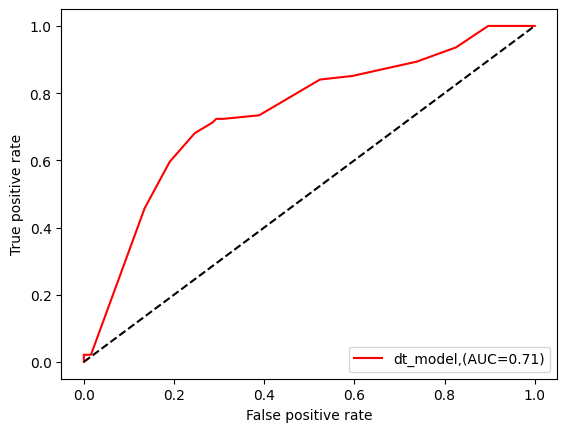

In [23]:
fpr,tpr,threshold=roc_curve(y_test,dt_model.predict_proba(x_test)[:,1])
fpr,tpr,threshold
auc=roc_auc_score(y_test,y_pred_test)
print(auc)
import matplotlib.pyplot as plt
plt.plot(fpr,tpr,color="red",label="dt_model,(AUC=%0.2f)"%auc)
plt.legend(loc="lower right")
plt.plot([0,1],[0,1],"k--")
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.show()

================================================================================================================================